STEP 1: READ/UPLOAD DATASET IN GOOGLE COLAB

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Songs Dataset.xlsx to Songs Dataset.xlsx


Import Required Libraries

In [2]:
import pandas as pd
import numpy as np

Load the Dataset

In [3]:
df = pd.read_excel('/content/Songs Dataset.xlsx')
df.head()

,No.,Song Title,Genre,Name of Artist,Album,Year of Release,Year of Published,Duration of Song,Country,Number of Streams
0,1,Same Mistakes,Indie,Paulo Alampay,King of Sadtown,2026,2026,03:14:00,Philippines,3341632.0
1,2,She Likes to Dance,Indie,Paulo Alampay,King of Sadtown,2026,2026,04:05:00,Philippines,2200000.0
2,3,Islands,Indie,Paulo Alampay,King of Sadtown,2026,2026,04:20:00,Philippines,2995270.0
3,4,I Broke My Heart,Indie,Paulo Alampay,King of Sadtown,2026,2026,02:52:00,Philippines,2000000.0
4,5,Sad Love Song,Indie,Paulo Alampay,King of Sadtown,2026,2026,04:26:00,Philippines,1850000.0


STEP 2: ANALYZE AND EVALUATE DATA

In [4]:
# Analyze Data
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   No.                100 non-null    int64  
 1   Song Title         100 non-null    object 
 2   Genre              100 non-null    object 
 3   Name of Artist     100 non-null    object 
 4   Album              100 non-null    object 
 5   Year of Release    100 non-null    int64  
 6   Year of Published  100 non-null    int64  
 7   Duration of Song   100 non-null    object 
 8   Country            100 non-null    object 
 9   Number of Streams  77 non-null     float64
dtypes: float64(1), int64(3), object(6)
memory usage: 7.9+ KB


,0
No.,0
Song Title,0
Genre,0
Name of Artist,0
Album,0
Year of Release,0
Year of Published,0
Duration of Song,0
Country,0
Number of Streams,23


STEP 3: DATA PREPROCESSING

In [5]:
# Remove unnecessary columns
df = df.drop(columns=['No.', 'Year of Published'], errors='ignore')

In [6]:
# Remove commas
df['Number of Streams'] = df['Number of Streams'].astype(str).str.replace(',', '')

# Convert to numeric
df['Number of Streams'] = pd.to_numeric(df['Number of Streams'], errors='coerce')

# Fill missing numeric values
df['Number of Streams'] = df['Number of Streams'].fillna(df['Number of Streams'].median())

# Handle missing text values
text_columns = ['Song Title','Genre','Name of Artist','Album','Country']
for col in text_columns:
    df[col] = df[col].fillna('unknown')

In [7]:
# Convert duration to seconds
df['Duration of Song'] = df['Duration of Song'].apply(lambda x: x.minute*60 + x.second)

In [8]:
# Normalize text
df['Song Title'] = df['Song Title'].str.lower()
df['Name of Artist'] = df['Name of Artist'].str.lower()
df['Genre'] = df['Genre'].str.lower()

In [9]:
# Create search column
df['search_text'] = (
    df['Song Title'] + " " +
    df['Name of Artist'] + " " +
    df['Genre'] + " " +
    df['Album']
)

df['search_text'] = df['search_text'].str.lower()

In [10]:
df = df.drop_duplicates() # Remove Duplicates

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Song Title         99 non-null     object 
 1   Genre              100 non-null    object 
 2   Name of Artist     100 non-null    object 
 3   Album              100 non-null    object 
 4   Year of Release    100 non-null    int64  
 5   Duration of Song   100 non-null    int64  
 6   Country            100 non-null    object 
 7   Number of Streams  100 non-null    float64
 8   search_text        99 non-null     object 
dtypes: float64(1), int64(2), object(6)
memory usage: 7.2+ KB


PLOT DATASET

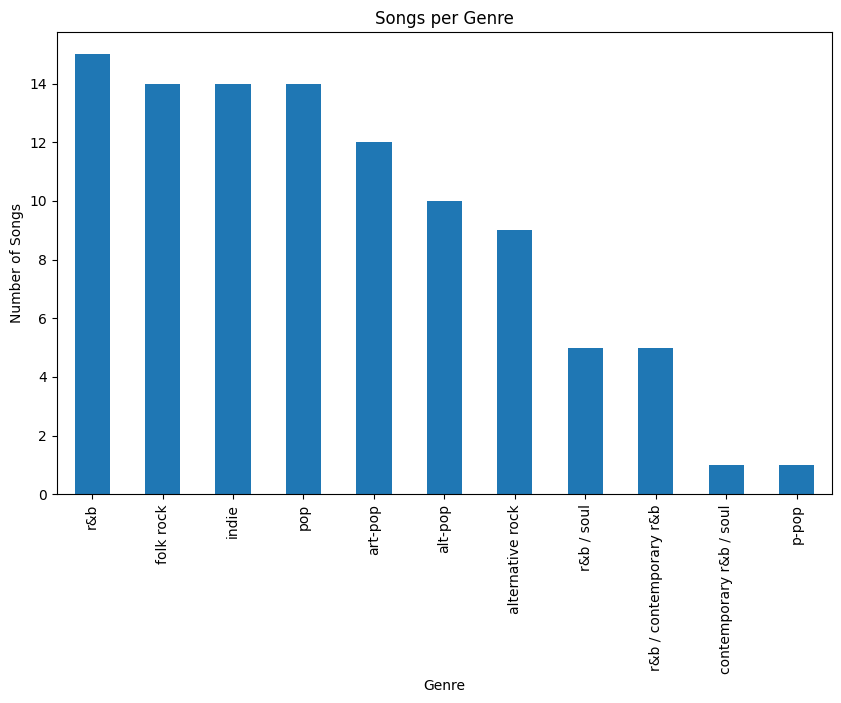

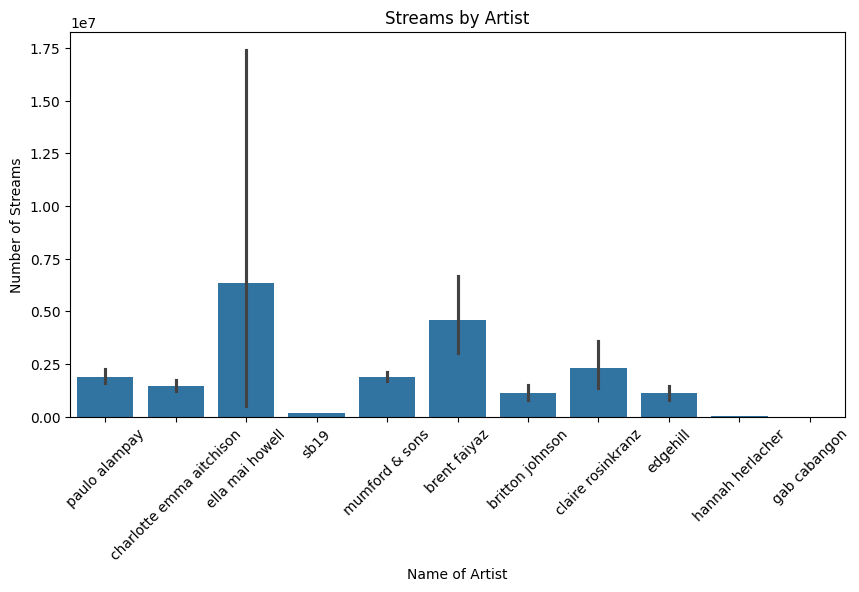

In [12]:

import matplotlib.pyplot as plt
import seaborn as sns

# Plot for Songs per Genre
plt.figure(figsize=(10,6))
df['Genre'].value_counts().plot(kind='bar')
plt.title('Songs per Genre')
plt.xlabel('Genre')
plt.ylabel('Number of Songs')
plt.show()

# Plot for Streams
plt.figure(figsize=(10,5))
sns.barplot(x='Name of Artist', y='Number of Streams', data=df)
plt.xticks(rotation=45)
plt.title("Streams by Artist")
plt.show()

STEP 5: Save Preprocessed Dataset (Deliverable #1)

In [13]:
df.to_csv("preprocessed_songs_dataset.csv", index=False)

In [14]:
files.download("preprocessed_songs_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

STEP 6: Simple Search System (Backend Logic)

In [ ]:
def search_song(query):
    query = query.lower()
    results = df[df['search_text'].str.contains(query)]
    return results[['Song Title', 'Name of Artist', 'Genre']]

STEP 7: Simple UI in Colab (Deliverable #2)

In [ ]:
import pandas as pd
import gradio as gr

# Load your dataset
df = pd.read_csv("/content/preprocessed_songs_dataset.csv")

# Function to search songs
def search_songs(query):
    if query.strip() == "":
        return "Enter a search term"
    # Make everything lowercase and search
    mask = df.apply(lambda row: row.astype(str).str.contains(query, case=False).any(), axis=1)
    results = df[mask]
    if results.empty:
        return "No results found"
    return results

# Gradio interface
iface = gr.Interface(
    fn=search_songs,
    inputs=gr.Textbox(label="Search for a song"),
    outputs=gr.Dataframe(label="Results")
)

iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://214cb5055b84dcd99a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
